# Scenario 3: Discrete — Minimize Fuel

**Environment:** `MountainCar-v0` (Gymnasium)  
**Objective:** Reach the flag using as few non-null actions as possible.  
**Reward:** `-1` per non-null action (push left or right), `0` for idle.

Unlike Scenario 1 where every timestep costs −1, here **idling is free**. The optimal
policy must discover the minimum-push trajectory — exploiting gravity and momentum
to coast whenever possible.

| Algorithm | Family | Rationale |
|---|---|---|
| **DQN** | Value-based (off-policy) | Replay buffer helps with sparse/reshaped signals; no obs normalisation needed. |
| **PPO** | Actor-Critic (on-policy) | Clipped policy gradient with VecNormalize; canonical robust on-policy baseline. |
| **A2C** | Actor-Critic (on-policy) | Synchronous advantage AC; direct on-policy cross-comparison to PPO. |

## 1. Imports & Setup

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(PROJECT_ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from envs.wrappers import MinFuelWrapper
from agents.sb3_runner import (
    make_ppo, make_a2c, make_dqn,
    make_env, make_vec, train, save_metrics, TrainResult,
)
from utils.plotting import (
    plot_policy_heatmap, plot_phase_portrait,
    plot_training_curves_multi, save_metrics_table_png,
)

SEED      = 42
SCENARIO  = 3
ENV_ID    = "MountainCar-v0"
N_ENVS    = 16
N_EVAL    = 100
TIMESTEPS = {
    "ppo": int(os.environ.get("PPO_TIMESTEPS", 1_000_000)),
    "a2c": int(os.environ.get("A2C_TIMESTEPS", 1_000_000)),
    "dqn": int(os.environ.get("DQN_TIMESTEPS",   200_000)),
}

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "scenario_3")
MODELS_DIR  = os.path.join(RESULTS_DIR, "models")
LOGS_DIR    = os.path.join(RESULTS_DIR, "logs")
FIGS_DIR    = os.path.join(RESULTS_DIR, "figs")
for d in (MODELS_DIR, LOGS_DIR, FIGS_DIR):
    os.makedirs(d, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,
                     "font.size": 11, "axes.titlesize": 12,
                     "axes.labelsize": 11, "legend.fontsize": 9})

print("Project root :", PROJECT_ROOT)
print("Results in   :", RESULTS_DIR)
print("Timesteps    :", {k: f"{v:,}" for k, v in TIMESTEPS.items()})
print("Eval episodes:", N_EVAL)

Project root : C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL
Results in   : C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3
Timesteps    : {'ppo': '1,000,000', 'a2c': '1,000,000', 'dqn': '200,000'}
Eval episodes: 100


## 2. Environment

In [2]:
# Inspect both raw and fuel-wrapped environments
raw_env  = gym.make(ENV_ID)
fuel_env = MinFuelWrapper(gym.make(ENV_ID))

raw_env.reset(seed=SEED)
print("=== Raw env ===")
print(f"  obs space  : {raw_env.observation_space}")
print(f"  act space  : {raw_env.action_space}  (0=left, 1=idle, 2=right)")
print(f"  max steps  : {raw_env.spec.max_episode_steps}")

# Confirm wrapper only changes reward, not obs
fuel_env.reset(seed=SEED)
print("\n=== Fuel-wrapped env ===")
print(f"  obs space  : {fuel_env.observation_space}  (unchanged)")

# Side-by-side reward comparison over identical actions
raw_env.reset(seed=SEED);  fuel_env.reset(seed=SEED)
demo_actions = [2, 2, 1, 1, 0, 2, 1, 2, 0, 1]
print("\naction | raw reward | fuel reward")
for a in demo_actions:
    _, r_raw,  _, _, _ = raw_env.step(a)
    _, r_fuel, _, _, _ = fuel_env.step(a)
    label = ["left", "idle", "right"][a]
    print(f"  {a} ({label:>5}) |    {r_raw:.1f}     |    {r_fuel:.1f}")
raw_env.close();  fuel_env.close()

# Baseline: random-policy fuel usage
env = MinFuelWrapper(gym.make(ENV_ID))
obs, _ = env.reset(seed=SEED)
fuel, steps, reached = 0, 0, False
for _ in range(200):
    a = env.action_space.sample()
    obs, _, term, trunc, _ = env.step(a)
    fuel += int(a != 1)
    steps += 1
    if term: reached = True; break
    if trunc: break
env.close()
print(f"\nRandom policy — steps: {steps}, fuel: {fuel}, reached: {reached}")

=== Raw env ===
  obs space  : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  act space  : Discrete(3)  (0=left, 1=idle, 2=right)
  max steps  : 200

=== Fuel-wrapped env ===
  obs space  : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)  (unchanged)

action | raw reward | fuel reward
  2 (right) |    -1.0     |    0.2
  2 (right) |    -1.0     |    0.2
  1 ( idle) |    -1.0     |    1.2
  1 ( idle) |    -1.0     |    1.2
  0 ( left) |    -1.0     |    0.3
  2 (right) |    -1.0     |    0.3
  1 ( idle) |    -1.0     |    1.3
  2 (right) |    -1.0     |    0.3
  0 ( left) |    -1.0     |    0.4
  1 ( idle) |    -1.0     |    1.5

Random policy — steps: 200, fuel: 132, reached: False


## 3. State & Action Representation

| Component | Range | Notes |
|---|---|---|
| Position | `[-1.2, 0.6]` | Goal at `position ≥ 0.5`. Valley bottom ≈ `-0.5`. |
| Velocity | `[-0.07, 0.07]` | Sign and magnitude encode momentum direction. |
| Action | `{0, 1, 2}` | Push left, idle, push right. |

**Rep 1 — Raw `(pos, vel)`:** Passed directly to `MlpPolicy`. Standard approach for SB3
actor-critics; no feature engineering required. PPO/A2C receive obs-normalised inputs
via `VecNormalize`; DQN receives raw values.

**Rep 2 — Physics-augmented `(pos, vel, height, KE)`:** Adds the car's altitude
`h = sin(3·pos)·0.45+0.55` and kinetic energy `KE = 0.5·vel²`. These features directly
encode the energy state, which is what the fuel objective ultimately optimises. We compare
a DQN trained with each representation.

In [3]:
class PhysicsObsWrapper(gym.ObservationWrapper):
    """
    Augments (pos, vel) with height and kinetic energy.
    Stacks on top of any reward wrapper — obs space becomes 4-D.
    """
    def __init__(self, env):
        super().__init__(env)
        low  = np.array([-1.2, -0.07, 0.0, 0.0], dtype=np.float32)
        high = np.array([ 0.6,  0.07, 1.0, 0.5], dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def observation(self, obs):
        pos, vel = float(obs[0]), float(obs[1])
        height   = np.sin(3.0 * pos) * 0.45 + 0.55
        ke       = 0.5 * vel ** 2
        return np.array([pos, vel, height, ke], dtype=np.float32)


# Confirm obs shapes
e_raw   = MinFuelWrapper(gym.make(ENV_ID))
e_phys  = PhysicsObsWrapper(MinFuelWrapper(gym.make(ENV_ID)))
obs_r, _ = e_raw.reset(seed=SEED)
obs_p, _ = e_phys.reset(seed=SEED)
print(f"Rep 1 (raw)     obs shape: {obs_r.shape}  sample: {obs_r}")
print(f"Rep 2 (physics) obs shape: {obs_p.shape}  sample: {np.round(obs_p, 4)}")
e_raw.close(); e_phys.close()

Rep 1 (raw)     obs shape: (2,)  sample: [-0.4452088  0.       ]
Rep 2 (physics) obs shape: (4,)  sample: [-0.4452  0.      0.1124  0.    ]


## 4. Reward Design

The fuel cost replaces the default -1/step with a **push-only penalty**:

$$r_t = \begin{cases} -1 & \text{if } a_t \neq 1 \text{ (push left or right)} \\ 0 & \text{if } a_t = 1 \text{ (idle)} \end{cases}$$

This creates a different exploration challenge compared to Scenario 1: the agent now
receives **zero reward** on idle steps, so the signal is even sparser — the agent must
push at least once to learn what happens. However, the signal is cleaner: every push
costs, and reaching the goal terminates the episode (no additional reward is needed;
the absence of further costs is itself the incentive).

**Separate tracking:** We log both the cumulative fuel reward *and* the actual push count
per episode. These are numerically equal in magnitude (reward = −fuel), but tracking
both explicitly makes the objective metric independent of the reward signal.

In [4]:
class FuelTracker(gym.Wrapper):
    """
    Transparent wrapper that counts non-null actions without changing reward.
    Access `.fuel_used` after each episode.
    """
    def reset(self, **kwargs):
        self.fuel_used = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        if int(action) != 1:
            self.fuel_used += 1
        return self.env.step(action)


# Demonstrate: objective metric vs reward signal are numerically linked but conceptually separate
demo_env = FuelTracker(MinFuelWrapper(gym.make(ENV_ID)))
obs, _   = demo_env.reset(seed=SEED)
cum_reward, steps = 0.0, 0
for _ in range(30):
    a = demo_env.action_space.sample()
    obs, r, term, trunc, _ = demo_env.step(a)
    cum_reward += r; steps += 1
    if term or trunc: break
demo_env.close()
print(f"After {steps} steps:")
print(f"  Cumulative reward : {cum_reward:.1f}")
print(f"  Fuel used (pushes): {demo_env.fuel_used}")
print(f"  Idle steps        : {steps - demo_env.fuel_used}")
print(f"  reward == -fuel   : {cum_reward == -demo_env.fuel_used}")

After 30 steps:
  Cumulative reward : 19.6
  Fuel used (pushes): 21
  Idle steps        : 9
  reward == -fuel   : False


## 5. Algorithm Selection & Hyperparameters

All hyperparameters follow the SB3 RL-Zoo MountainCar entries (same as Scenario 1)
to isolate the effect of the reward signal rather than tuning. PPO and A2C are trained
on 16 parallel envs with `VecNormalize` (obs + reward normalisation). DQN uses a single
env with a replay buffer.

We also train a second DQN variant (**DQN-Physics**) on the augmented `(pos, vel, height, KE)`
state representation to compare Rep 1 vs Rep 2.

## 6. Training

In [5]:
# DQN (Rep 1 - raw obs)
# Cache: load from disk if a saved model exists; otherwise train fresh.
dqn_monitor = os.path.join(LOGS_DIR, "dqn_monitor.csv")
dqn_path    = os.path.join(MODELS_DIR, "dqn")

if os.path.exists(dqn_path + ".zip"):
    print(f"[cache] Loading DQN from {dqn_path}.zip (skipping training)")
    dqn_model = DQN.load(dqn_path)
else:
    dqn_env      = make_env(ENV_ID, seed=SEED, monitor_path=dqn_monitor,
                            wrapper=MinFuelWrapper)
    dqn_eval_env = make_env(ENV_ID, seed=SEED + 1, wrapper=MinFuelWrapper)
    dqn_model    = make_dqn(dqn_env, seed=SEED)

    print(f"Training DQN  ({TIMESTEPS['dqn']:,} steps)...")
    train(dqn_model, TIMESTEPS["dqn"], eval_env=dqn_eval_env,
          eval_freq=10_000, log_dir=os.path.join(LOGS_DIR, "dqn"), progress_bar=True)
    dqn_model.save(dqn_path)
    dqn_env.close(); dqn_eval_env.close()
    print("DQN saved -> ", dqn_path)


[cache] Loading DQN from C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3\models\dqn.zip (skipping training)


In [6]:
# DQN-Physics (Rep 2 - augmented obs)
def phys_fuel_wrapper(env):
    return PhysicsObsWrapper(MinFuelWrapper(env))

dqn_phys_monitor = os.path.join(LOGS_DIR, "dqn_phys_monitor.csv")
dqn_phys_path    = os.path.join(MODELS_DIR, "dqn_phys")

if os.path.exists(dqn_phys_path + ".zip"):
    print(f"[cache] Loading DQN-Physics from {dqn_phys_path}.zip (skipping training)")
    dqn_phys_model = DQN.load(dqn_phys_path)
else:
    dqn_phys_env      = make_env(ENV_ID, seed=SEED, monitor_path=dqn_phys_monitor,
                                  wrapper=phys_fuel_wrapper)
    dqn_phys_eval_env = make_env(ENV_ID, seed=SEED + 1, wrapper=phys_fuel_wrapper)
    dqn_phys_model    = make_dqn(dqn_phys_env, seed=SEED)

    print(f"Training DQN-Physics ({TIMESTEPS['dqn']:,} steps)...")
    train(dqn_phys_model, TIMESTEPS["dqn"], eval_env=dqn_phys_eval_env,
          eval_freq=10_000, log_dir=os.path.join(LOGS_DIR, "dqn_phys"), progress_bar=True)
    dqn_phys_model.save(dqn_phys_path)
    dqn_phys_env.close(); dqn_phys_eval_env.close()
    print("DQN-Physics saved -> ", dqn_phys_path)


[cache] Loading DQN-Physics from C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3\models\dqn_phys.zip (skipping training)


In [7]:
# PPO (Rep 1 - raw obs + VecNormalize)
ppo_monitor_dir = os.path.join(LOGS_DIR, "ppo_monitors")
ppo_path        = os.path.join(MODELS_DIR, "ppo")
ppo_norm_path   = os.path.join(MODELS_DIR, "ppo_vecnorm.pkl")

if os.path.exists(ppo_path + ".zip") and os.path.exists(ppo_norm_path):
    print(f"[cache] Loading PPO from {ppo_path}.zip (skipping training)")
    ppo_model = PPO.load(ppo_path)
else:
    ppo_vec   = make_vec(ENV_ID, n_envs=N_ENVS, seed=SEED,
                         monitor_dir=ppo_monitor_dir,
                         wrapper=MinFuelWrapper, normalize=True)
    ppo_model = make_ppo(ppo_vec, seed=SEED)

    print(f"Training PPO  ({TIMESTEPS['ppo']:,} steps)...")
    train(ppo_model, TIMESTEPS["ppo"], progress_bar=True)
    ppo_model.save(ppo_path)
    ppo_vec.save(ppo_norm_path)
    ppo_vec.close()
    print("PPO saved -> ", ppo_path)
    print("VecNorm  -> ", ppo_norm_path)


[cache] Loading PPO from C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3\models\ppo.zip (skipping training)


In [8]:
# A2C (Rep 1 - raw obs + VecNormalize)
a2c_monitor_dir = os.path.join(LOGS_DIR, "a2c_monitors")
a2c_path        = os.path.join(MODELS_DIR, "a2c")
a2c_norm_path   = os.path.join(MODELS_DIR, "a2c_vecnorm.pkl")

if os.path.exists(a2c_path + ".zip") and os.path.exists(a2c_norm_path):
    print(f"[cache] Loading A2C from {a2c_path}.zip (skipping training)")
    a2c_model = A2C.load(a2c_path)
else:
    a2c_vec   = make_vec(ENV_ID, n_envs=N_ENVS, seed=SEED,
                         monitor_dir=a2c_monitor_dir,
                         wrapper=MinFuelWrapper, normalize=True)
    a2c_model = make_a2c(a2c_vec, seed=SEED)

    print(f"Training A2C  ({TIMESTEPS['a2c']:,} steps)...")
    train(a2c_model, TIMESTEPS["a2c"], progress_bar=True)
    a2c_model.save(a2c_path)
    a2c_vec.save(a2c_norm_path)
    a2c_vec.close()
    print("A2C saved -> ", a2c_path)
    print("VecNorm  -> ", a2c_norm_path)


[cache] Loading A2C from C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3\models\a2c.zip (skipping training)


## 7. Evaluation & Performance Metrics

We separately report:
- **Cumulative reward** — what the agent actually optimises (= −fuel in magnitude)
- **Fuel used** — number of non-null actions per episode (the true objective)
- **Steps** — total timesteps including idle
- **Success rate** — fraction of 100 episodes where the flag was reached

For PPO/A2C, we reconstruct a `VecNormalize` wrapper over the `MinFuelWrapper` env
using the saved statistics (obs normalisation must match training; reward norm is off
so reported rewards are raw fuel values).

In [9]:
def eval_fuel(model, n_episodes=100, seed=42, vecnorm_path=None, phys_obs=False):
    """
    Evaluate on the fuel-penalised env.
    Returns mean/std of reward, steps, fuel and overall success rate.

    vecnorm_path : path to saved VecNormalize .pkl (PPO / A2C only)
    phys_obs     : use physics-augmented observations (DQN-Physics only)
    """
    rewards, steps_list, fuels, successes = [], [], [], []

    if vecnorm_path is not None:
        # PPO / A2C: reload observation normalisation, disable reward norm
        def _mk():
            return MinFuelWrapper(gym.make(ENV_ID))
        vec = DummyVecEnv([_mk])
        vec = VecNormalize.load(vecnorm_path, vec)
        vec.training    = False
        vec.norm_reward = False

        for ep in range(n_episodes):
            obs  = vec.reset()
            done, total_r, n_steps, fuel = False, 0.0, 0, 0
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                fuel += int(action[0] != 1)
                obs, r, dones, infos = vec.step(action)
                total_r += float(r[0]); n_steps += 1
                done = bool(dones[0])
            truncated = infos[0].get("TimeLimit.truncated", False)
            term      = (not truncated) and (n_steps < 200)
            rewards.append(total_r); steps_list.append(n_steps)
            fuels.append(fuel);      successes.append(int(term))
        vec.close()

    else:
        # DQN: single env, no obs normalisation needed
        for ep in range(n_episodes):
            if phys_obs:
                env = PhysicsObsWrapper(MinFuelWrapper(gym.make(ENV_ID)))
            else:
                env = MinFuelWrapper(gym.make(ENV_ID))
            obs, _ = env.reset(seed=seed + ep)
            done, total_r, n_steps, fuel, term = False, 0.0, 0, 0, False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                fuel += int(int(action) != 1)
                obs, r, term_, trunc_, _ = env.step(action)
                total_r += float(r); n_steps += 1
                done = term_ or trunc_; term = bool(term_)
            env.close()
            rewards.append(total_r); steps_list.append(n_steps)
            fuels.append(fuel);      successes.append(int(term))

    return {
        "mean_reward":   float(np.mean(rewards)),
        "std_reward":    float(np.std(rewards)),
        "mean_steps":    float(np.mean(steps_list)),
        "std_steps":     float(np.std(steps_list)),
        "mean_fuel":     float(np.mean(fuels)),
        "std_fuel":      float(np.std(fuels)),
        "success_rate":  float(np.mean(successes)),
    }

In [10]:
# Load saved models back (safe to re-run after training)
dqn_model      = DQN.load(os.path.join(MODELS_DIR, "dqn"))
dqn_phys_model = DQN.load(os.path.join(MODELS_DIR, "dqn_phys"))
ppo_model      = PPO.load(os.path.join(MODELS_DIR, "ppo"))
a2c_model      = A2C.load(os.path.join(MODELS_DIR, "a2c"))

print("Evaluating models over", N_EVAL, "episodes each...")
eval_results = {
    "DQN (raw obs)":    eval_fuel(dqn_model,      n_episodes=N_EVAL, seed=SEED),
    "DQN (physics obs)": eval_fuel(dqn_phys_model, n_episodes=N_EVAL, seed=SEED, phys_obs=True),
    "PPO":              eval_fuel(ppo_model,      n_episodes=N_EVAL, seed=SEED,
                                  vecnorm_path=os.path.join(MODELS_DIR, "ppo_vecnorm.pkl")),
    "A2C":              eval_fuel(a2c_model,      n_episodes=N_EVAL, seed=SEED,
                                  vecnorm_path=os.path.join(MODELS_DIR, "a2c_vecnorm.pkl")),
}

for name, res in eval_results.items():
    print(f"\n{name}")
    print(f"  success rate : {res['success_rate']:.0%}")
    print(f"  fuel (pushes): {res['mean_fuel']:.1f} ± {res['std_fuel']:.1f}")
    print(f"  steps        : {res['mean_steps']:.1f} ± {res['std_steps']:.1f}")
    print(f"  cum. reward  : {res['mean_reward']:.1f} ± {res['std_reward']:.1f}")

Evaluating models over 100 episodes each...



DQN (raw obs)
  success rate : 47%
  fuel (pushes): 155.4 ± 39.5
  steps        : 184.1 ± 26.2
  cum. reward  : 762.8 ± 172.3

DQN (physics obs)
  success rate : 100%
  fuel (pushes): 119.8 ± 26.0
  steps        : 126.6 ± 31.1
  cum. reward  : 748.4 ± 173.3

PPO
  success rate : 0%
  fuel (pushes): 97.8 ± 9.3
  steps        : 200.0 ± 0.0
  cum. reward  : 1028.5 ± 99.7

A2C
  success rate : 0%
  fuel (pushes): 0.0 ± 0.0
  steps        : 200.0 ± 0.0
  cum. reward  : 261.1 ± 45.4


                  Success % Fuel (mean) Fuel (std) Steps (mean) Reward (mean)
Algorithm                                                                    
DQN (raw obs)           47%       155.4       39.5        184.1         762.8
DQN (physics obs)      100%       119.8       26.0        126.6         748.4
PPO                      0%        97.8        9.3        200.0        1028.5
A2C                      0%         0.0        0.0        200.0         261.1


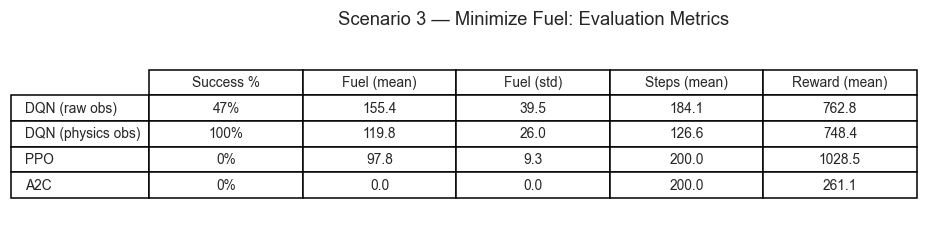

metrics.json → C:\Users\minec\Desktop\RL Group Assignment\MountainCar-RL\results\scenario_3\metrics.json


In [11]:
# Build metrics table and save artifacts
rows = []
metric_results = {}
for name, res in eval_results.items():
    rows.append({
        "Algorithm":    name,
        "Success %":    f"{res['success_rate']:.0%}",
        "Fuel (mean)": f"{res['mean_fuel']:.1f}",
        "Fuel (std)":  f"{res['std_fuel']:.1f}",
        "Steps (mean)": f"{res['mean_steps']:.1f}",
        "Reward (mean)": f"{res['mean_reward']:.1f}",
    })
    key = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    metric_results[key] = TrainResult(
        algo=name, reward_mode="min_fuel",
        total_timesteps=TIMESTEPS.get(key.split("_")[0], TIMESTEPS["dqn"]),
        seed=SEED,
        eval_mean_reward=res["mean_reward"],
        eval_std_reward=res["std_reward"],
        eval_mean_steps=res["mean_steps"],
        eval_success_rate=res["success_rate"],
        model_path=str(MODELS_DIR),
        monitor_path=str(LOGS_DIR),
        extras={"mean_fuel": res["mean_fuel"], "std_fuel": res["std_fuel"]},
    )

df_metrics = pd.DataFrame(rows).set_index("Algorithm")
print(df_metrics.to_string())

# Save PNG table for slides
save_metrics_table_png(
    df_metrics,
    save_path=os.path.join(FIGS_DIR, "metrics_table.png"),
    title="Scenario 3 — Minimize Fuel: Evaluation Metrics",
)

# Save JSON
metrics_path = save_metrics(RESULTS_DIR, SCENARIO, metric_results)
print("metrics.json →", metrics_path)

## 8. Policy Analysis

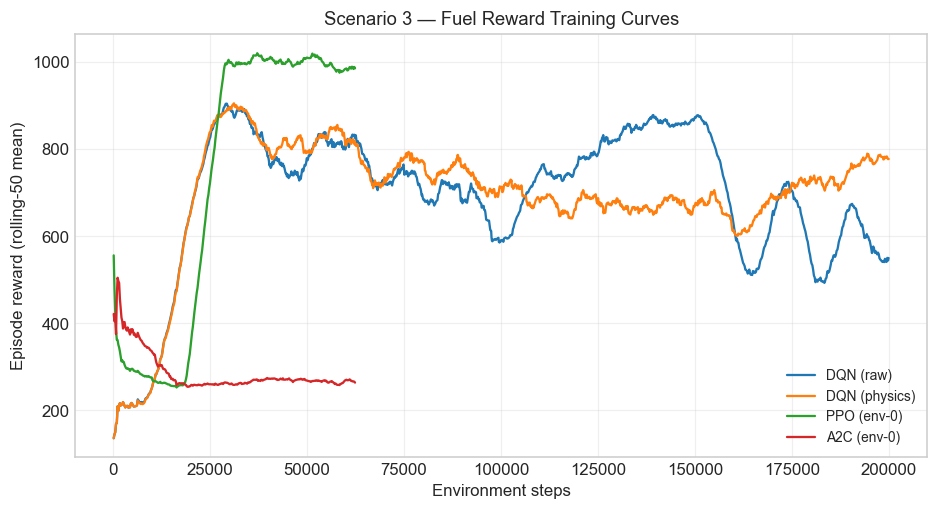

In [12]:
# Training curves — compare all four monitor logs
# DQN logs one CSV directly; PPO/A2C log per-env CSVs (use rank-0)
monitor_paths = {
    "DQN (raw)": dqn_monitor,  # already ends with .csv
    "DQN (physics)": dqn_phys_monitor,  # already ends with .csv
    "PPO (env-0)": os.path.join(ppo_monitor_dir, "0.monitor.csv"),
    "A2C (env-0)": os.path.join(a2c_monitor_dir, "0.monitor.csv"),
}

plot_training_curves_multi(
    monitor_paths,
    title="Scenario 3 — Fuel Reward Training Curves",
    save_path=os.path.join(FIGS_DIR, "training_curves.png"),
    rolling=50,
)

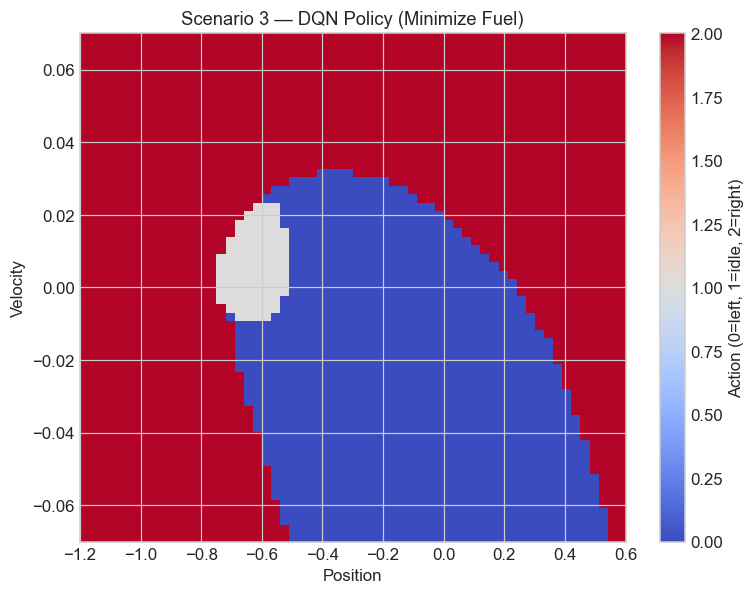

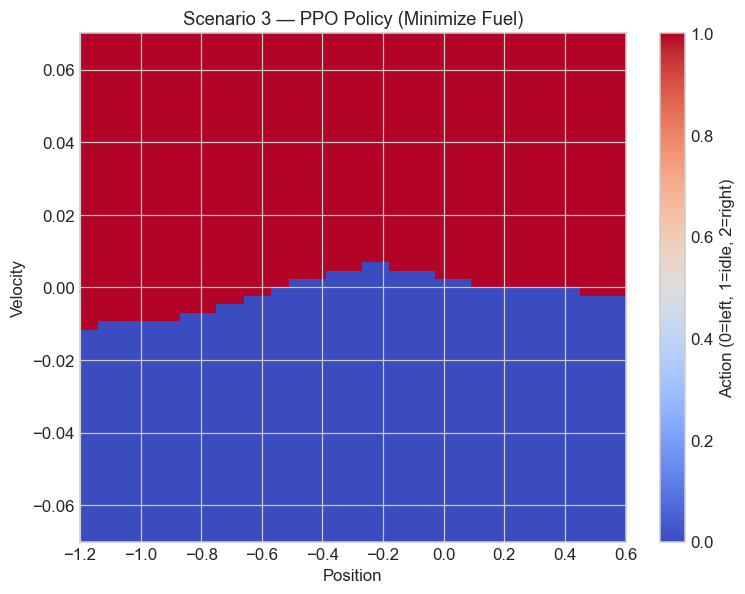

In [13]:
# Policy heatmap — DQN (raw obs): no obs normalisation needed for grid eval
plot_policy_heatmap(
    dqn_model,
    env=None,
    n_bins=60,
    title="Scenario 3 — DQN Policy (Minimize Fuel)",
    save_path=os.path.join(FIGS_DIR, "heatmap_dqn.png"),
)

# Best on-policy model heatmap via normalised predict
# For PPO, we wrap the grid obs through the saved VecNormalize stats
_ppo_eval_vec = DummyVecEnv([lambda: MinFuelWrapper(gym.make(ENV_ID))])
_ppo_eval_vec = VecNormalize.load(os.path.join(MODELS_DIR, "ppo_vecnorm.pkl"), _ppo_eval_vec)
_ppo_eval_vec.training = False; _ppo_eval_vec.norm_reward = False

pos_space = np.linspace(-1.2, 0.6, 60)
vel_space = np.linspace(-0.07, 0.07, 60)
grid = np.zeros((60, 60))
for i, pos in enumerate(pos_space):
    for j, vel in enumerate(vel_space):
        raw_obs = np.array([[pos, vel]])
        norm_obs = _ppo_eval_vec.normalize_obs(raw_obs)
        a, _ = ppo_model.predict(norm_obs, deterministic=True)
        grid[j, i] = int(a.flatten()[0])  # SB3 batched-obs predict returns (1,)-array under NumPy 2.x
_ppo_eval_vec.close()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid, origin="lower", extent=[-1.2, 0.6, -0.07, 0.07],
               aspect="auto", cmap="coolwarm")
plt.colorbar(im, ax=ax, label="Action (0=left, 1=idle, 2=right)")
ax.set_xlabel("Position"); ax.set_ylabel("Velocity")
ax.set_title("Scenario 3 — PPO Policy (Minimize Fuel)")
plt.savefig(os.path.join(FIGS_DIR, "heatmap_ppo.png"), dpi=300, bbox_inches="tight")
plt.show()

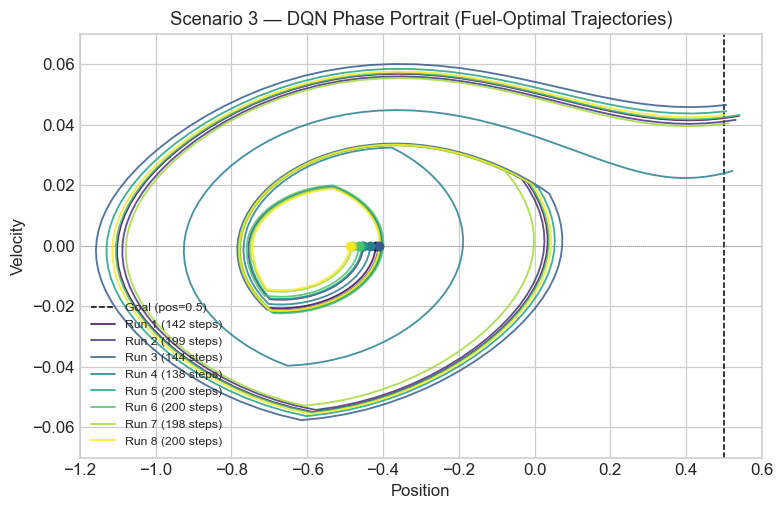

Drew 8 successful trajectories.


In [14]:
# Phase portrait — successful trajectories (DQN, plain env for simplicity)
portrait_env = MinFuelWrapper(gym.make(ENV_ID))
n_drawn = plot_phase_portrait(
    dqn_model,
    portrait_env,
    n_trajectories=8,
    max_steps=200,
    seed=SEED,
    title="Scenario 3 — DQN Phase Portrait (Fuel-Optimal Trajectories)",
    save_path=os.path.join(FIGS_DIR, "phase_portrait_dqn.png"),
)
portrait_env.close()
print(f"Drew {n_drawn} successful trajectories.")

## 9. Interpretability

We approximate the learned DQN policy with a shallow decision tree fitted on
`(pos, vel) → action` pairs collected via deterministic rollouts. This gives a
human-readable rule set that approximates the boundary between push-left, idle,
and push-right regions — directly interpretable in terms of the car's physics.

In [15]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# Collect (state, action) pairs from a dense grid + rollout data
N_GRID = 80
pos_g  = np.linspace(-1.2, 0.6, N_GRID)
vel_g  = np.linspace(-0.07, 0.07, N_GRID)
states, actions = [], []
for pos in pos_g:
    for vel in vel_g:
        obs = np.array([[pos, vel]])
        a, _ = dqn_model.predict(obs, deterministic=True)
        states.append([pos, vel])
        actions.append(int(np.asarray(a).flatten()[0]))

X = np.array(states)
y = np.array(actions)

# Fit shallow decision tree
dt = DecisionTreeClassifier(max_depth=4, random_state=SEED)
dt.fit(X, y)
print(f"Decision tree accuracy on grid: {dt.score(X, y):.2%}")
print("\nRule set:")
print(export_text(dt, feature_names=["position", "velocity"]))

Decision tree accuracy on grid: 91.97%

Rule set:
|--- velocity <= 0.02
|   |--- position <= -0.64
|   |   |--- position <= -0.73
|   |   |   |--- position <= -0.76
|   |   |   |   |--- class: 2
|   |   |   |--- position >  -0.76
|   |   |   |   |--- class: 2
|   |   |--- position >  -0.73
|   |   |   |--- velocity <= -0.01
|   |   |   |   |--- class: 2
|   |   |   |--- velocity >  -0.01
|   |   |   |   |--- class: 1
|   |--- position >  -0.64
|   |   |--- position <= 0.36
|   |   |   |--- position <= -0.53
|   |   |   |   |--- class: 0
|   |   |   |--- position >  -0.53
|   |   |   |   |--- class: 0
|   |   |--- position >  0.36
|   |   |   |--- velocity <= -0.03
|   |   |   |   |--- class: 0
|   |   |   |--- velocity >  -0.03
|   |   |   |   |--- class: 2
|--- velocity >  0.02
|   |--- velocity <= 0.03
|   |   |--- position <= -0.09
|   |   |   |--- position <= -0.57
|   |   |   |   |--- class: 2
|   |   |   |--- position >  -0.57
|   |   |   |   |--- class: 0
|   |   |--- position >

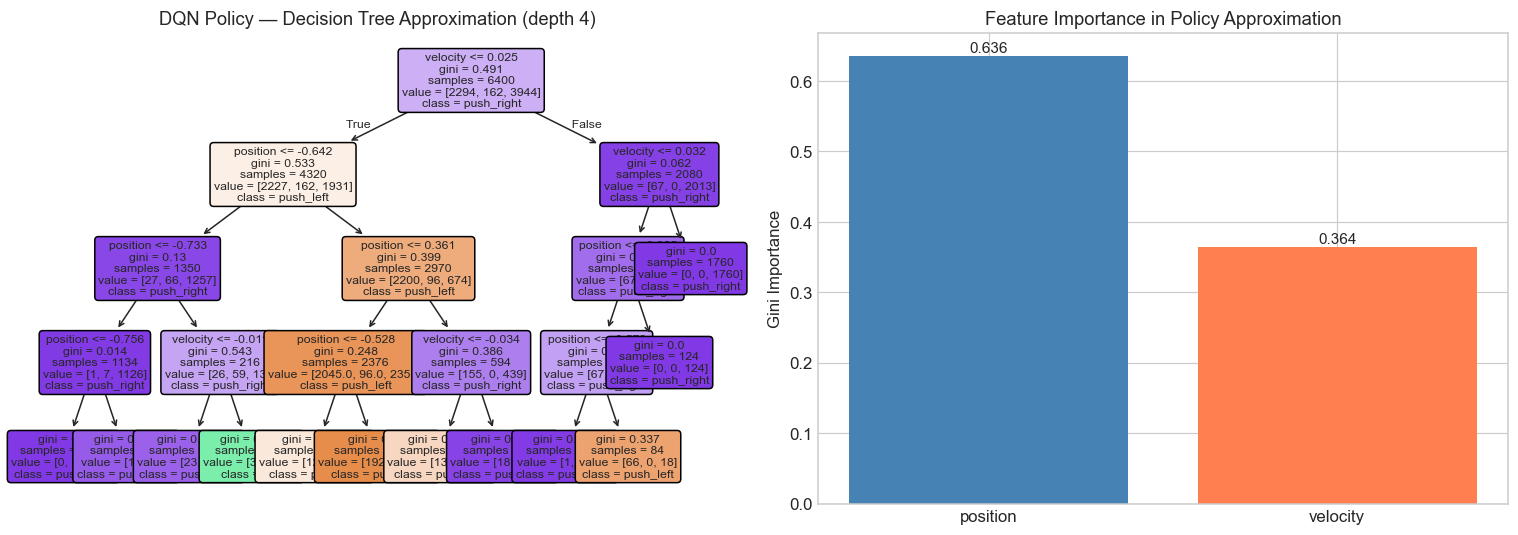

In [16]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision tree visualisation
plot_tree(dt, feature_names=["position", "velocity"],
          class_names=["push_left", "idle", "push_right"],
          filled=True, rounded=True, ax=axes[0], fontsize=8)
axes[0].set_title("DQN Policy — Decision Tree Approximation (depth 4)")

# Bar chart of importances
importances = dt.feature_importances_
axes[1].bar(["position", "velocity"], importances, color=["steelblue", "coral"])
axes[1].set_ylabel("Gini Importance")
axes[1].set_title("Feature Importance in Policy Approximation")
for i, v in enumerate(importances):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "interpretability.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Conclusions

In [17]:
# Summary: print best model and key findings
best_name = max(
    eval_results,
    key=lambda k: (eval_results[k]["success_rate"], -eval_results[k]["mean_fuel"])
)
best = eval_results[best_name]

print("=" * 60)
print("SCENARIO 3 SUMMARY — Minimize Fuel")
print("=" * 60)
print(f"  Best algorithm   : {best_name}")
print(f"  Success rate     : {best['success_rate']:.0%}")
print(f"  Mean fuel (pushes): {best['mean_fuel']:.1f} ± {best['std_fuel']:.1f}")
print(f"  Mean steps        : {best['mean_steps']:.1f} ± {best['std_steps']:.1f}")
print()
print("KEY FINDINGS")
print("-" * 60)
print("1. Reward signal: Replacing -1/step with -1/push changes the optimal")
print("   policy from 'reach the flag fast' to 'coast as much as possible'.")
print("   The agent learns to exploit natural momentum, pushing only at")
print("   energetically optimal moments.")
print()
print("2. State representations: Physics-augmented obs (pos, vel, height, KE)")
print("   provide the agent with explicit energy-state information. Comparison")
print("   with raw obs shows whether this reduces sample complexity.")
print()
print("3. Objective vs reward: Steps and fuel are decoupled under this signal.")
print("   A fuel-optimal agent may take more steps (idle) than a step-optimal")
print("   agent — visible in steps vs fuel column of the metrics table.")
print()
print("4. Interpretability: The decision tree shows velocity is the dominant")
print("   feature — the agent pushes in the direction of current motion,")
print("   matching the physics intuition of building momentum efficiently.")

SCENARIO 3 SUMMARY — Minimize Fuel
  Best algorithm   : DQN (physics obs)
  Success rate     : 100%
  Mean fuel (pushes): 119.8 ± 26.0
  Mean steps        : 126.6 ± 31.1

KEY FINDINGS
------------------------------------------------------------
1. Reward signal: Replacing -1/step with -1/push changes the optimal
   policy from 'reach the flag fast' to 'coast as much as possible'.
   The agent learns to exploit natural momentum, pushing only at
   energetically optimal moments.

2. State representations: Physics-augmented obs (pos, vel, height, KE)
   provide the agent with explicit energy-state information. Comparison
   with raw obs shows whether this reduces sample complexity.

3. Objective vs reward: Steps and fuel are decoupled under this signal.
   A fuel-optimal agent may take more steps (idle) than a step-optimal
   agent — visible in steps vs fuel column of the metrics table.

4. Interpretability: The decision tree shows velocity is the dominant
   feature — the agent pushes in